In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   
import seaborn as sns

In [2]:
df=pd.read_csv('Salary_Dataset_DSL.csv')

In [3]:
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


In [4]:
print(df.shape)

(22770, 8)


In [5]:
df.describe().astype(int)

,Rating,Salary,Salaries Reported
count,22770,22770,22770
mean,3,695387,1
std,0,884399,6
min,1,2112,1
25%,3,300000,1
50%,3,500000,1
75%,4,900000,1
max,5,90000000,361


# checking some datas 

In [6]:
df.isnull().sum()

Rating               0
Company Name         1
Job Title            0
Salary               0
Salaries Reported    0
Location             0
Employment Status    0
Job Roles            0
dtype: int64

In [7]:
#check which have null Company Name
df[df['Company Name'].isnull()]

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
13760,4.0,NaN,Software Development Engineer,1188000,1,Bangalore,Full Time,SDE


In [8]:
#show all duplicate rows
df[df.duplicated()]

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles


In [9]:
#count total duplicates
df.duplicated().sum()

np.int64(0)

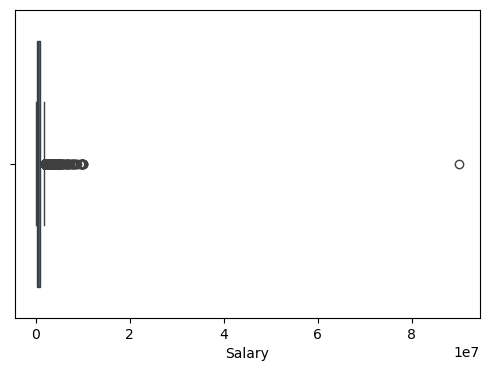

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Salary'])
plt.title='Salary Outliers'
plt.show()

# removing outliers

In [11]:
Q1 = df['Salary'].quantile(0.25)

Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1 #IQR = Interquartile Range (It is the middle 50% range of our data.)

lower_limit = Q1 - 1.5 * IQR # any value below this 

upper_limit = Q3 + 1.5 * IQR   # any avlue above this as consider as outliers

In [12]:
df = df[(df['Salary'] >= lower_limit) & (df['Salary'] <= upper_limit)]

In [13]:
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


In [14]:
Q1 = df['Salary'].quantile(0.25)

Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1 #IQR = Interquartile Range (It is the middle 50% range of our data.)

lower_limit = Q1 - 1.5 * IQR # any value below this 

upper_limit = Q3 + 1.5 * IQR   # any avlue above this as consider as outliers
df = df[(df['Salary'] >= lower_limit) & (df['Salary'] <= upper_limit)]

In [15]:
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


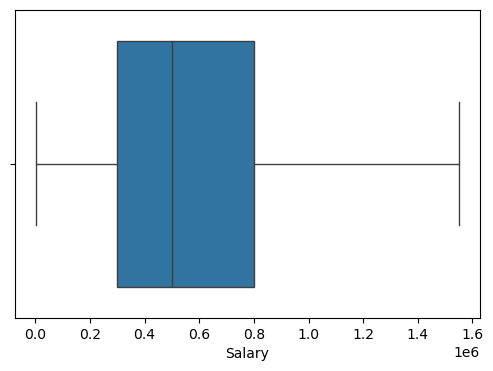

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Salary'])
plt.title='Salary Outliers'
plt.show()

# Salary distribution

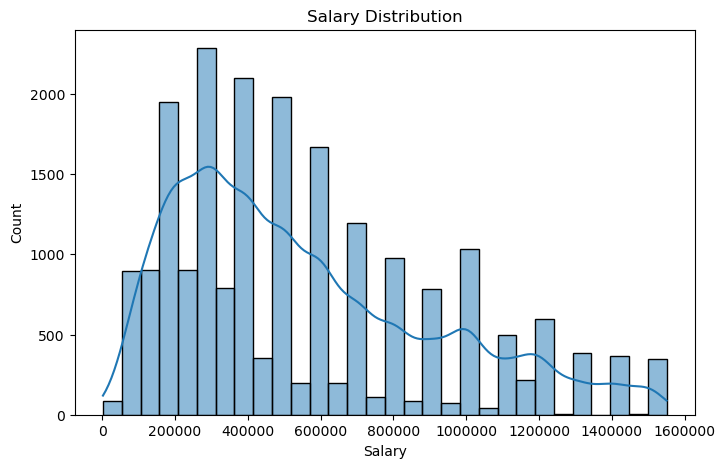

In [17]:
fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(df['Salary'], bins=30, kde=True, ax=ax)

ax.ticklabel_format(style='plain', axis='x')

ax.set_title('Salary Distribution')
ax.set_xlabel('Salary')


ax.set_ylabel('Count')
plt.savefig("salary_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

# Higest salary job roles

In [18]:
high_salary=df.groupby('Job Roles')['Salary'].mean().sort_values(ascending=False)
high_salary

Job Roles
Database    702554.768392
SDE         648182.534714
IOS         593214.068241
Mobile      589857.819905
Backend     529104.564347
Frontend    501977.282203
Android     483352.318634
Java        475832.116985
Testing     464824.757895
Python      449531.694295
Web         392554.089069
Name: Salary, dtype: float64

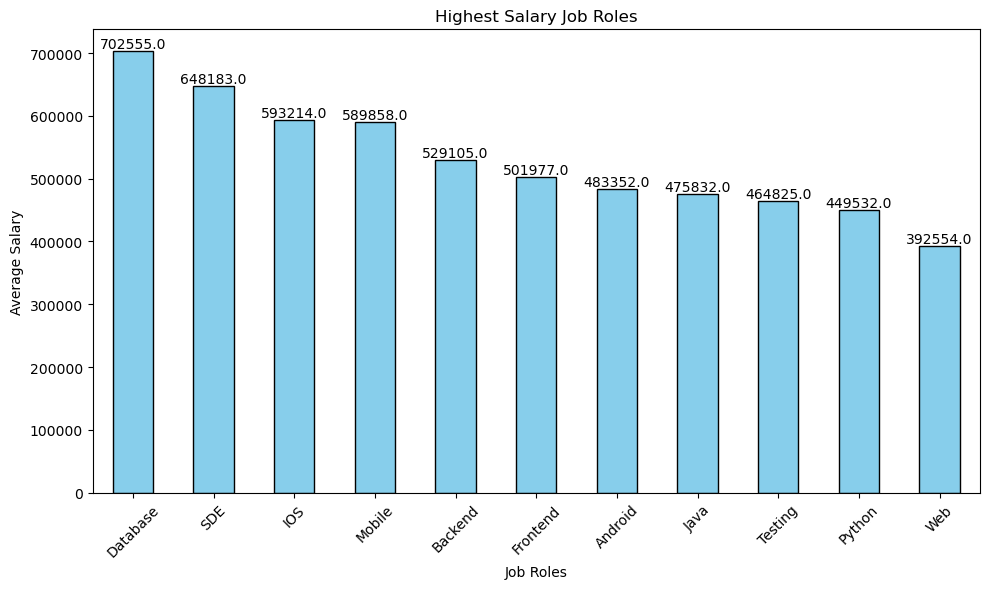

In [19]:
fig, ax = plt.subplots(figsize=(10,6))

high_salary.plot(
    kind='bar',
    color='skyblue',
    edgecolor='black',
    ax=ax
)

ax.set_title('Highest Salary Job Roles')
ax.set_xlabel('Job Roles')
ax.set_ylabel('Average Salary')
ax.tick_params(axis='x', rotation=45)

ax.ticklabel_format(style='plain', axis='y')
for i, value in enumerate(high_salary):
    ax.text(i, value, str(round(value, 0)),
            ha='center', va='bottom')


plt.tight_layout()
plt.savefig("high_pay_jobs.png", dpi=300, bbox_inches='tight')

plt.show()

In [20]:
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


# which cities has higest salary

In [21]:
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


In [22]:
city_salary=df.groupby('Location')['Salary'].mean().sort_values(ascending=False)

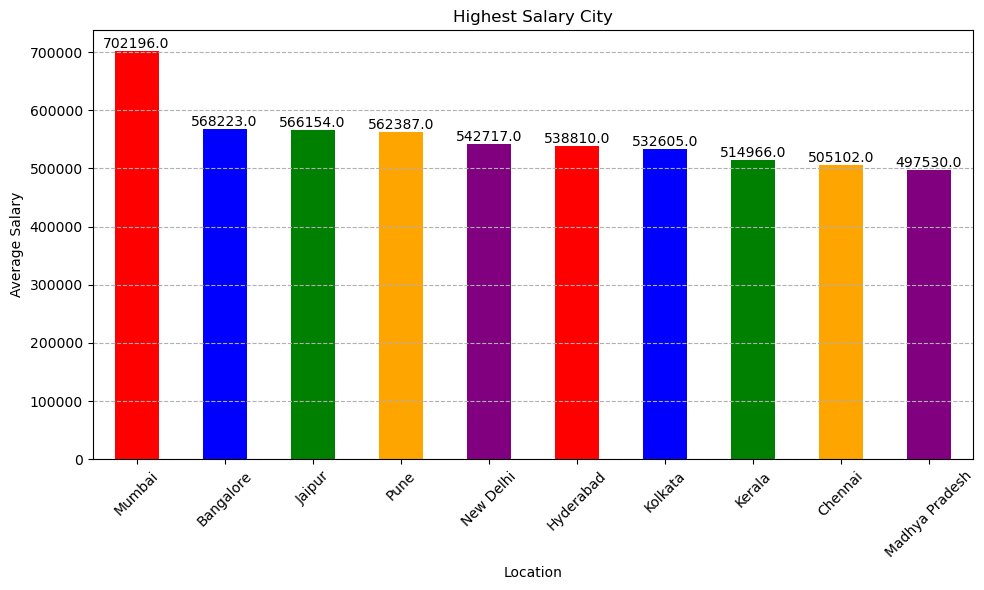

In [23]:
colors = ['red', 'blue', 'green', 'orange', 'purple']

fig, ax = plt.subplots(figsize=(10,6))

city_salary.plot(
    kind='bar',
    color=colors,
    ax=ax
)
ax.set_title('Highest Salary City')
ax.set_ylabel('Average Salary')
ax.tick_params(axis='x', rotation=45)
ax.ticklabel_format(style='plain', axis='y')
ax.grid(axis='y',linestyle='--',alpha=1)
 
for i, value in enumerate(city_salary):
    ax.text(i, value, str(round(value, 0)),
            ha='center', va='bottom')

plt.tight_layout()
plt.savefig("high_salary_cities.png", dpi=300, bbox_inches='tight')

plt.show()

# Company in delhi and has 5 star Rating

In [24]:
high_delhi_com=df[(df['Location']=='New Delhi') & (df['Rating']==5)].sort_values(by='Salary',ascending=False)

In [25]:
high_delhi_com['Company Name'].head()

6750                      Hapramp
1888                     Trillbit
17488     The Art of Mike Mignola
8284     Silicon Valley Recycling
17351             Parth Universal
Name: Company Name, dtype: object

In [26]:
high_delhi_com['Company Name'].tail()

1723         Neo Fitnes
1969      WorkingNation
2334      Hopin (India)
17524    Star Catalysts
18680            Atom 8
Name: Company Name, dtype: object

In [27]:
#most people with same job 
df['Job Title'].value_counts()

Job Title
Software Development Engineer          2137
Android Developer                      1983
Software Development Engineer (SDE)    1477
Front End Developer                    1360
Test Engineer                          1290
                                       ... 
Software Engineer III - IOS               1
Senior IOS Developer and Tech Lead        1
Associate Developer - IOS                 1
Senior Analyst (IOS/IPhone)               1
Associate Web Developer                   1
Name: count, Length: 981, dtype: int64

In [28]:
#hich job titles have the highest number of salary reports
df.groupby('Job Title')['Salaries Reported'].count().sort_values(ascending=False)

Job Title
Software Development Engineer                          2137
Android Developer                                      1983
Software Development Engineer (SDE)                    1477
Front End Developer                                    1360
Test Engineer                                          1290
                                                       ... 
Lead Software Development Engineer In Test Engineer       1
Lead Software Test Engineer                               1
Lead, IOS Team                                            1
Level II Mobile Technician                                1
Xamarin Mobile Developer                                  1
Name: Salaries Reported, Length: 981, dtype: int64

In [29]:
top_company_salary = (
    df.groupby('Company Name')
      .agg({
          'Salary': 'mean',
          'Salaries Reported': 'sum'
      })
)

#Keeping companies with at least 20 salary reports
top_company_salary = top_company_salary[
    top_company_salary['Salaries Reported'] >= 20
]

top_company_salary['Salary'] = (
    top_company_salary['Salary']
    .astype(int)
)

# Top 10 companies
top_company_salary = (
    top_company_salary
    .sort_values(by='Salary', ascending=False)
    .head(10)
)

print(top_company_salary)

                         Salary  Salaries Reported
Company Name                                      
Mobile Premier League   1183333                 20
Druva                   1071428                 21
Walmart                 1070666                 34
Citrix                  1060800                 35
Urban Company           1056666                 22
Applied Research Works  1050000                 21
ZestMoney               1038285                 22
PayPal                  1037777                 51
Adobe                   1013052                 58
Broadcom                1000000                 39


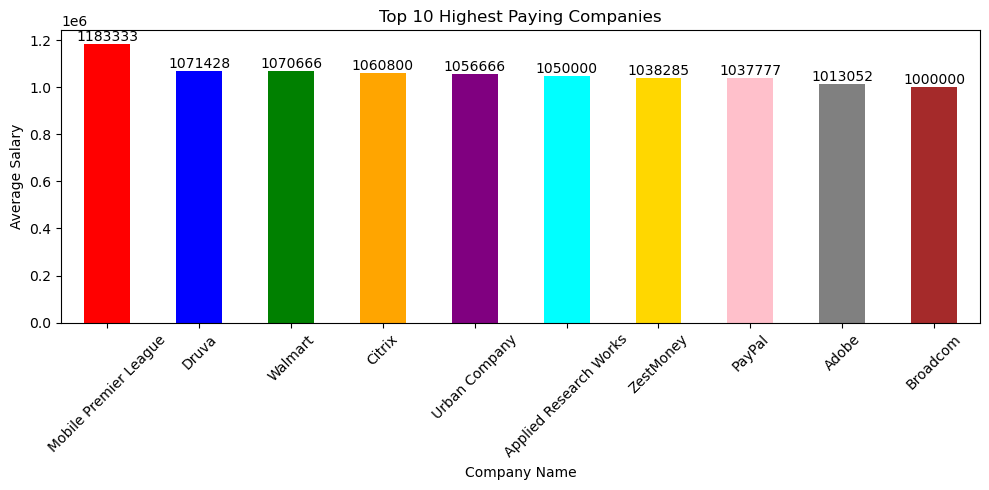

In [30]:
colors = [
    'red', 'blue', 'green', 'orange', 'purple',
    'cyan', 'gold', 'pink', 'gray', 'brown'
]

fig, ax = plt.subplots(figsize=(10,5))

top_company_salary['Salary'].plot(
    kind='bar',
    color=colors,
    ax=ax
)

ax.set_title('Top 10 Highest Paying Companies')
ax.set_ylabel('Average Salary')

ax.tick_params(axis='x', rotation=45)

# Add salary values on bars
for i, value in enumerate(top_company_salary['Salary']):
    ax.text(i, value, str(value),
            ha='center', va='bottom')

plt.tight_layout()
plt.savefig("top_paying_companies.png", dpi=300, bbox_inches='tight')

plt.show()

# Relation between Rating and salaries

In [31]:
corr=df.corr(numeric_only=True)

,Rating,Salary,Salaries Reported
Rating,1.000000,0.024772,-0.013516
Salary,0.024772,1.000000,-0.021672
Salaries Reported,-0.013516,-0.021672,1.000000


# Relationship using Heatmap

NameError: name 'corr' is not defined

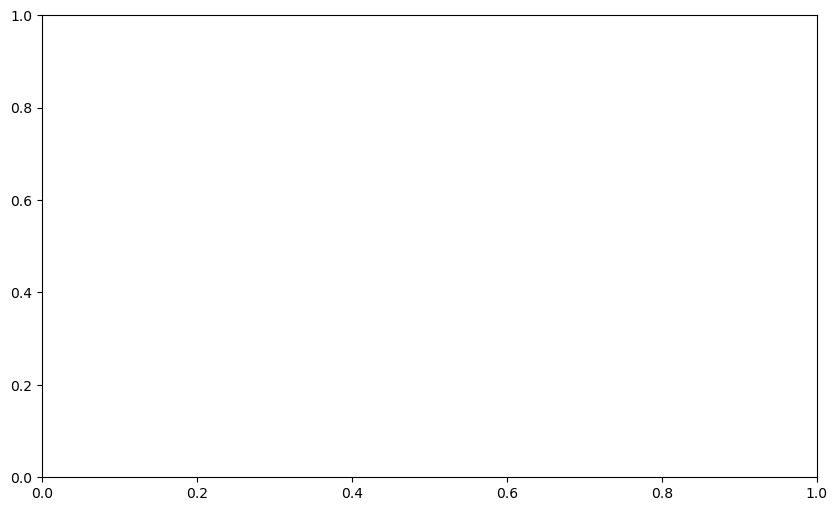

In [32]:
fig, ax = plt.subplots(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    ax=ax
)

ax.set_title('Correlation Heatmap')

ax.set_xlabel('Features')
ax.set_ylabel('Features')

plt.tight_layout()
plt.savefig("heatmap.png", dpi=300, bbox_inches='tight')

plt.show()

In [33]:
df['Employment Status'].unique()

array(['Full Time', 'Intern', 'Contractor', 'Trainee'], dtype=object)

In [34]:
df['Employment Status'].value_counts()

Employment Status
Full Time     18379
Intern         2089
Contractor      513
Trainee          33
Name: count, dtype: int64

# summary of salaries for each employment status group

In [35]:
summary_of_salaries= df.groupby('Employment Status')['Salary'].describe()
summary_of_salaries

,count,mean,std,min,25%,50%,75%,max
Employment Status,,,,,,,,
Contractor,513.0,501507.586745,315663.813209,12000.0,300000.0,400000.0,600000.0,1500000.0
Full Time,18379.0,579305.536101,358065.460032,8448.0,300000.0,500000.0,800000.0,1550000.0
Intern,2089.0,338353.991383,264180.887035,2112.0,144000.0,264000.0,456000.0,1500000.0
Trainee,33.0,324303.030303,241096.516572,96000.0,144000.0,240000.0,400000.0,1100000.0


# Top 10 Most Common Job Roles

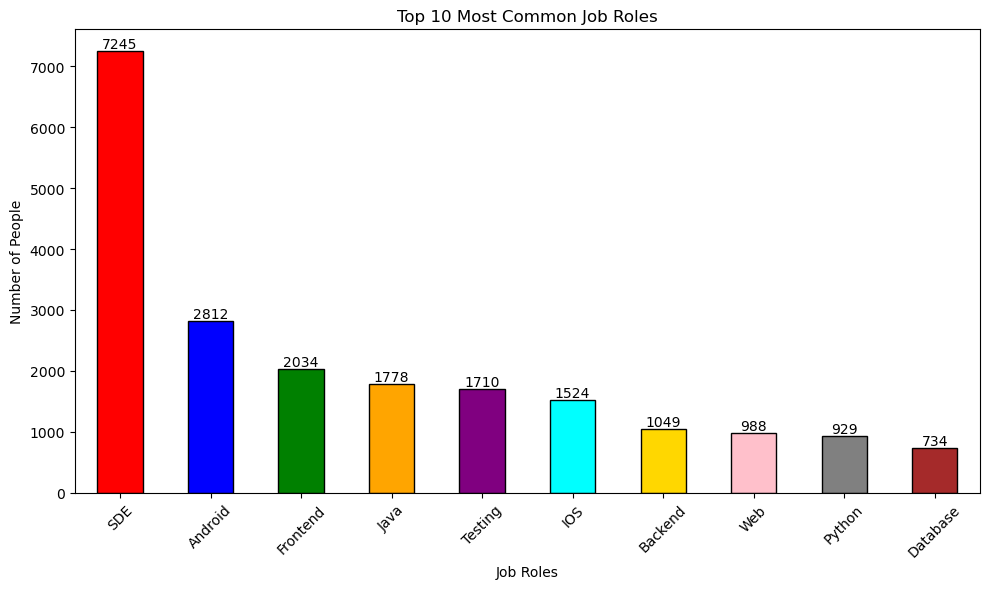

In [36]:
top_jobs = df['Job Roles'].value_counts().head(10)

colors = ['red', 'blue', 'green', 'orange', 'purple',
          'cyan', 'gold', 'pink', 'gray', 'brown']

fig, ax = plt.subplots(figsize=(10,6))

top_jobs.plot(
    kind='bar',
    color=colors,
    edgecolor='black',
    ax=ax
)

ax.set_title('Top 10 Most Common Job Roles')
ax.set_xlabel('Job Roles')
ax.set_ylabel('Number of People')

ax.tick_params(axis='x', rotation=45)

# Add numbers on top
for i, value in enumerate(top_jobs):
    ax.text(i, value, str(value),
            ha='center', va='bottom')

plt.tight_layout()
plt.savefig("top_job_roles.png", dpi=300, bbox_inches='tight')
plt.show()

 # Average salary trend across company Rating

In [37]:
x=df.groupby('Rating')['Salary'].mean().reset_index()
x.head()

,Rating,Salary
0,1.0,399971.500000
1,1.3,500000.000000
2,1.4,331200.000000
3,1.5,241000.000000
4,1.6,262285.714286


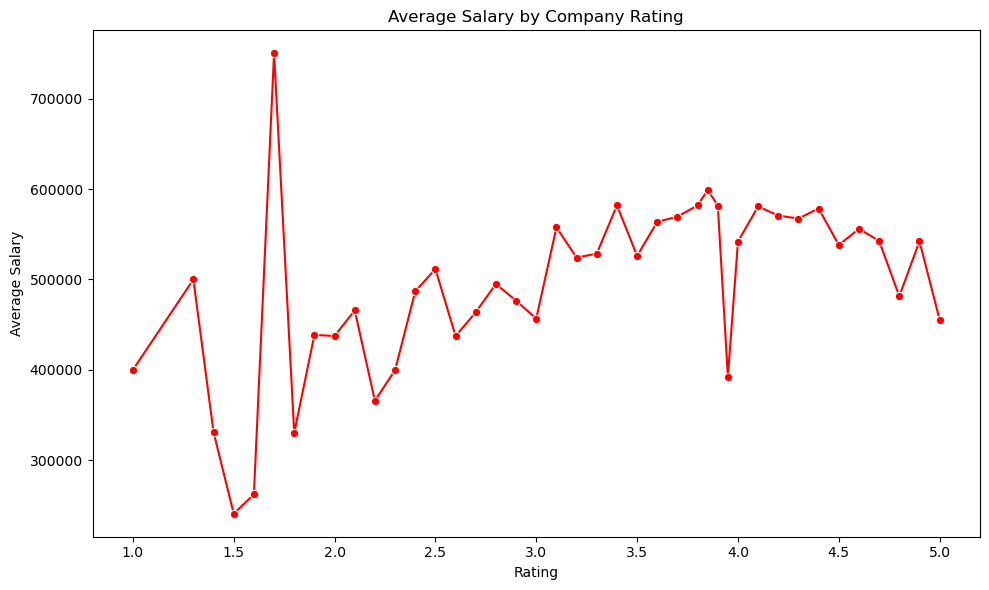

In [38]:
fig, ax = plt.subplots(figsize=(10,6))

sns.lineplot(
    x='Rating',
    y='Salary',
    data=x,
    marker='o',
    ax=ax,
    color='red'
)

ax.set_title('Average Salary by Company Rating')
ax.set_xlabel('Rating')
ax.set_ylabel('Average Salary')

# Save plot
plt.savefig("line_plot.png", dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

# Rating between 3-5 is more stable and consistant

In [39]:
df.columns

Index(['Rating', 'Company Name', 'Job Title', 'Salary', 'Salaries Reported',
       'Location', 'Employment Status', 'Job Roles'],
      dtype='object')

In [40]:

# Top 10 locations
top_10_locations = (
    df['Location']
    .value_counts()
    .head(10)
    .reset_index()
)

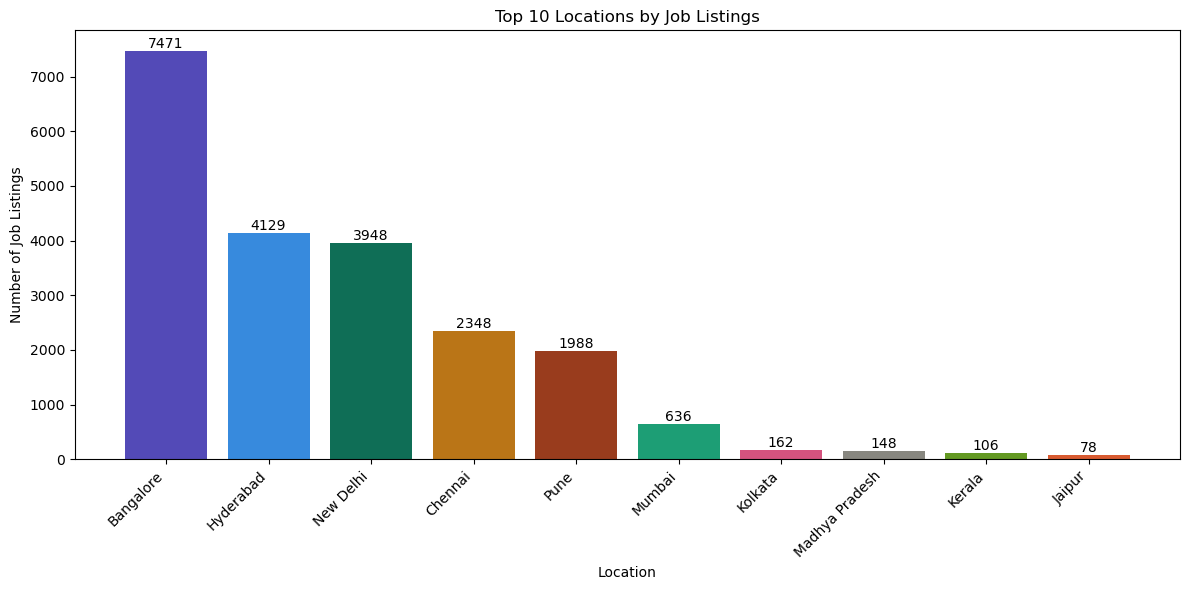

In [41]:

top_10_locations.columns = ['Location', 'Job Listings']

# Your color palette
colors = [
    '#534AB7', '#378add', '#0F6E56', '#BA7517', '#993C1D',
    '#1D9E75', '#D4537E', '#888780', '#639922', '#D85A30'
]

# Create figure
fig, ax = plt.subplots(figsize=(12,6))

# Bar plot
ax.bar(
    top_10_locations['Location'],
    top_10_locations['Job Listings'],
    color=colors
)

# Titles and labels
ax.set_title('Top 10 Locations by Job Listings')
ax.set_xlabel('Location')
ax.set_ylabel('Number of Job Listings')

# Rotate labels
plt.xticks(rotation=45, ha='right')

# Add value labels
for i, value in enumerate(top_10_locations['Job Listings']):
    ax.text(i, value, str(value),
            ha='center', va='bottom')

plt.tight_layout()
plt.show()